## Draw the 3D geometry

Found 124 non-origin box geometries.


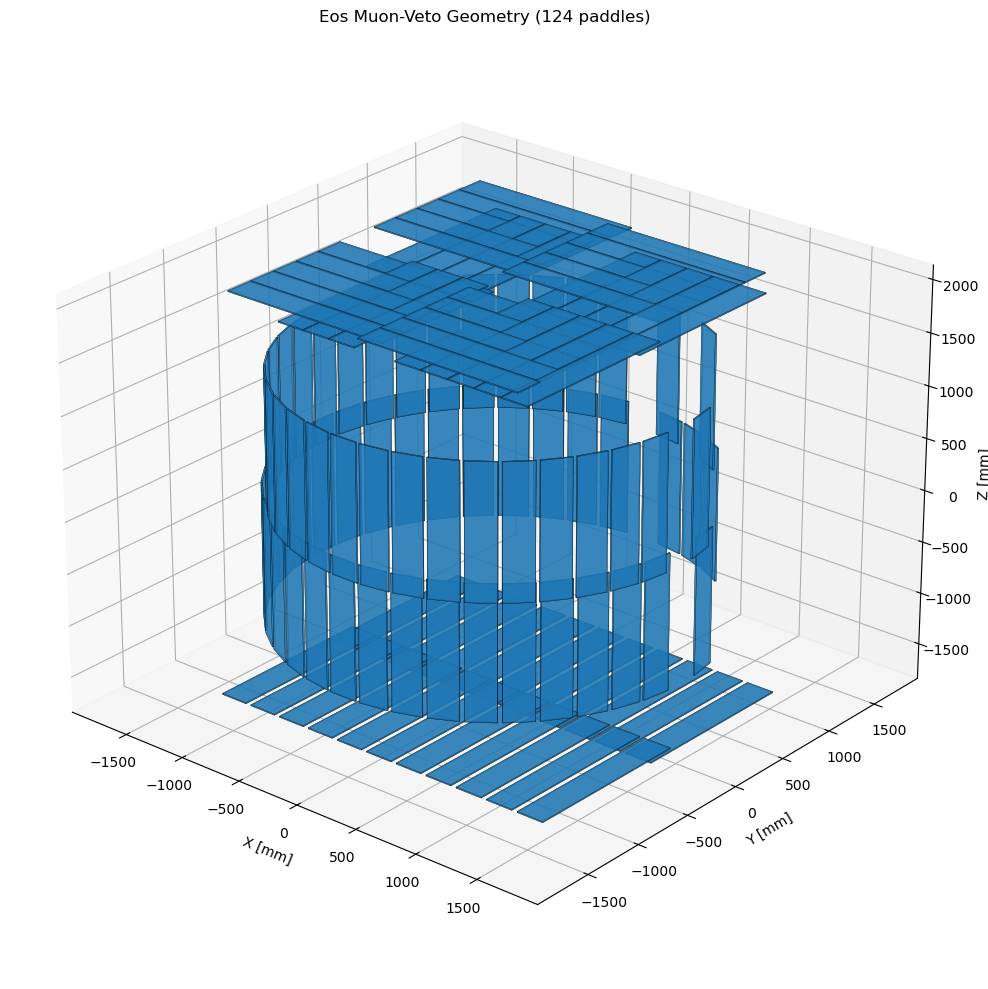

In [27]:
import re
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

GEO_FILE = "/home/wto/Eos/EosSimulations/ratdb/Eos/MuonPaddles.geo"

# Draw paddle IDs at their centers
SHOW_LABELS = False

# Save figure if desired, e.g. "muon_veto_geometry.png"
# Set to None to only display it.
OUTPUT_FILE = None


# ============================================================
# Read the .geo file
# ============================================================

with open(GEO_FILE, "r") as f:
    text = f.read()

# Remove // comments
text = re.sub(r'//.*', '', text)

# Find all {...} geometry blocks
blocks = re.findall(r'\{.*?\}', text, flags=re.DOTALL)

paddles = []

for block in blocks:

    # Only keep type: "box"
    type_match = re.search(
        r'type\s*:\s*"([^"]+)"',
        block,
        flags=re.IGNORECASE
    )

    if not type_match:
        continue

    if type_match.group(1).lower() != "box":
        continue

    # Read index/name
    index_match = re.search(
        r'index\s*:\s*"([^"]+)"',
        block
    )

    if not index_match:
        continue

    name = index_match.group(1)

    # Read position
    position_match = re.search(
        r'position\s*:\s*\[([^\]]+)\]',
        block,
        flags=re.IGNORECASE
    )

    # Read rotation
    rotation_match = re.search(
        r'rotation\s*:\s*\[([^\]]+)\]',
        block,
        flags=re.IGNORECASE
    )

    # Read size
    size_match = re.search(
        r'size\s*:\s*\[([^\]]+)\]',
        block,
        flags=re.IGNORECASE
    )

    if position_match is None or size_match is None:
        continue

    position = np.array(
        [float(x.strip()) for x in position_match.group(1).split(",")],
        dtype=float
    )

    size = np.array(
        [float(x.strip()) for x in size_match.group(1).split(",")],
        dtype=float
    )

    if rotation_match is None:
        rotation = np.zeros(3)
    else:
        rotation = np.array(
            [float(x.strip()) for x in rotation_match.group(1).split(",")],
            dtype=float
        )

    # Ignore geometries at (0, 0, 0)
    if np.allclose(position, [0.0, 0.0, 0.0]):
        continue

    paddles.append({
        "name": name,
        "position": position,
        "rotation": rotation,
        "size": size
    })


print(f"Found {len(paddles)} non-origin box geometries.")

if len(paddles) == 0:
    raise RuntimeError("No non-origin box geometries found.")

# ============================================================
# Create 3D plot
# ============================================================

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

all_corners = []


# ============================================================
# Loop over paddles
# ============================================================

for paddle in paddles:

    position = paddle["position"]
    size = paddle["size"]
    rotation = paddle["rotation"]

    # RAT box size values are HALF-LENGTHS
    hx, hy, hz = size

    # Eight corners of the box in local coordinates
    corners = np.array([
        [-hx, -hy, -hz],
        [ hx, -hy, -hz],
        [ hx,  hy, -hz],
        [-hx,  hy, -hz],

        [-hx, -hy,  hz],
        [ hx, -hy,  hz],
        [ hx,  hy,  hz],
        [-hx,  hy,  hz]
    ])

    # Convert rotation from degrees to radians
    rx, ry, rz = np.radians(rotation)

    # Rotation matrix around X
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(rx), -np.sin(rx)],
        [0, np.sin(rx),  np.cos(rx)]
    ])

    # Rotation matrix around Y
    Ry = np.array([
        [ np.cos(ry), 0, np.sin(ry)],
        [0,           1, 0],
        [-np.sin(ry), 0, np.cos(ry)]
    ])

    # Rotation matrix around Z
    Rz = np.array([
        [np.cos(rz), -np.sin(rz), 0],
        [np.sin(rz),  np.cos(rz), 0],
        [0,           0,          1]
    ])

    # Combined rotation matrix
    R = Rz @ Ry @ Rx

    # Rotate the box
    corners = corners @ R.T

    # Move box to its world position
    corners += position

    all_corners.append(corners)

    # Define the six faces
    faces = [
        corners[[0, 1, 2, 3]],
        corners[[4, 5, 6, 7]],
        corners[[0, 1, 5, 4]],
        corners[[1, 2, 6, 5]],
        corners[[2, 3, 7, 6]],
        corners[[3, 0, 4, 7]]
    ]

    # Add box to plot
    collection = Poly3DCollection(
        faces,
        alpha=0.65,
        edgecolor="black",
        linewidth=0.25
    )

    ax.add_collection3d(collection)

    # Optional paddle number labels
    if SHOW_LABELS:
        x, y, z = position

        label = paddle["name"].replace("paddle_", "")

        ax.text(
            x,
            y,
            z,
            label,
            fontsize=6
        )


# ============================================================
# Set equal XYZ scale
# ============================================================

all_corners = np.vstack(all_corners)

mins = np.min(all_corners, axis=0)
maxs = np.max(all_corners, axis=0)

center = (mins + maxs) / 2.0
radius = np.max(maxs - mins) / 2.0

ax.set_xlim(
    center[0] - radius,
    center[0] + radius
)

ax.set_ylim(
    center[1] - radius,
    center[1] + radius
)

ax.set_zlim(
    center[2] - radius,
    center[2] + radius
)


# ============================================================
# Plot formatting
# ============================================================

ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_zlabel("Z [mm]")

ax.set_title(
    f"Eos Muon-Veto Geometry ({len(paddles)} paddles)"
)

# Initial viewing angle
ax.view_init(
    elev=25,
    azim=-50
)

plt.tight_layout()


# ============================================================
# Optional save
# ============================================================

if OUTPUT_FILE is not None:
    plt.savefig(
        OUTPUT_FILE,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved plot to {OUTPUT_FILE}")


plt.show()